In [1]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Test on one file first
audio_path = 'data/genres_original/blues/blues.00000.wav'
y, sr = librosa.load(audio_path, duration=30)

# MFCCs — most important feature for audio
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
print(f"MFCCs shape: {mfccs.shape}")
print(f"Mean of first MFCC: {mfccs[0].mean():.2f}")

MFCCs shape: (13, 1292)
Mean of first MFCC: -113.62


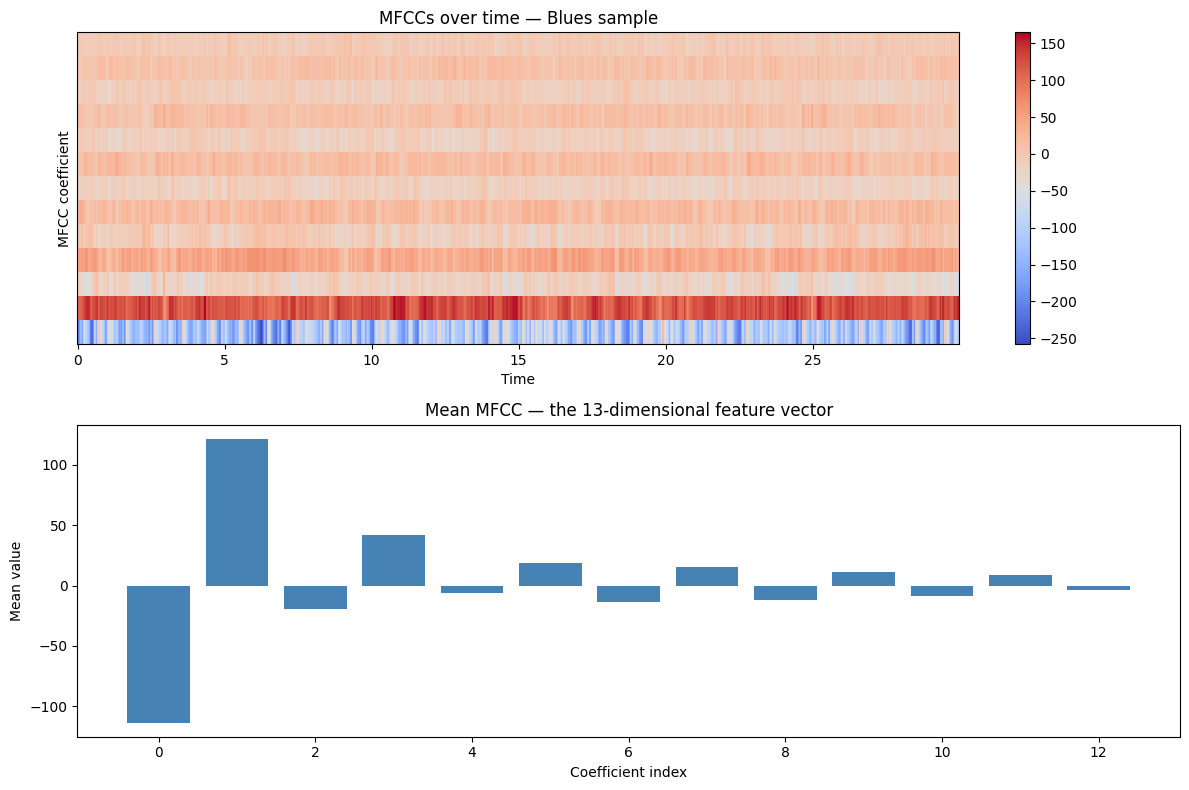

Feature vector shape: (13,)
Feature vector: [-113.62  121.55  -19.15   42.35   -6.37   18.61  -13.69   15.34  -12.28
   10.97   -8.32    8.81   -3.67]


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 1. Full MFCC matrix (time vs coefficient)
librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[0], cmap='coolwarm')
axes[0].set_title('MFCCs over time — Blues sample')
axes[0].set_ylabel('MFCC coefficient')
plt.colorbar(axes[0].collections[0], ax=axes[0])

# 2. Mean MFCC across time (the feature vector)
mfcc_mean = mfccs.mean(axis=1)
axes[1].bar(range(13), mfcc_mean, color='steelblue')
axes[1].set_title('Mean MFCC — the 13-dimensional feature vector')
axes[1].set_xlabel('Coefficient index')
axes[1].set_ylabel('Mean value')

plt.tight_layout()
plt.show()

print(f"Feature vector shape: {mfcc_mean.shape}")
print(f"Feature vector: {mfcc_mean.round(2)}")

In [3]:
import os

genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
          'jazz', 'metal', 'pop', 'reggae', 'rock']

features = []

for genre in genres:
    genre_path = f'data/genres_original/{genre}'
    for filename in os.listdir(genre_path):
        if filename.endswith('.wav'):
            file_path = os.path.join(genre_path, filename)
            try:
                y, sr = librosa.load(file_path, duration=30)
                mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
                mfcc_mean = mfccs.mean(axis=1)
                features.append([*mfcc_mean, genre])
            except Exception as e:
                print(f"Error with {filename}: {e}")

# Build DataFrame
columns = [f'mfcc_{i}' for i in range(13)] + ['genre']
df = pd.DataFrame(features, columns=columns)

print(df.shape)
print(df.head())
print(df['genre'].value_counts())

C:\Users\Dell\AppData\Local\Temp\ipykernel_20308\2396108937.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, duration=30)
C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Error with jazz.00054.wav: 
(999, 14)
       mfcc_0      mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5  \
0 -113.619385  121.553017 -19.151056  42.345768  -6.371168  18.613033   
1 -207.581512  123.997147   8.939115  35.870758   2.919971  21.518787   
2  -90.776344  140.448608 -29.100559  31.687340 -13.975973  25.741686   
3 -199.462006  150.094742   5.649167  26.870144   1.755440  14.236880   
4 -160.291855  126.195763 -35.602501  22.151167 -32.487640  10.862023   

      mfcc_6     mfcc_7     mfcc_8     mfcc_9    mfcc_10   mfcc_11   mfcc_12  \
0 -13.692060  15.339379 -12.283617  10.973775  -8.322410  8.806787 -3.665802   
1  -8.555368  23.355938 -10.101037  11.906445  -5.558123  5.375942 -2.237833   
2 -13.644712  11.623112 -11.775921   9.700466 -13.115349  5.785764 -8.899733   
3  -4.828873   9.297849  -0.753142   8.147393  -3.195236  6.085354 -2.476188   
4 -23.357162   0.500523 -11.804770   1.203878 -13.085074 -2.809849 -6.935621   

   genre  
0  blues  
1  blues  
2  blues 

In [4]:
df.to_csv('data/mfcc_features.csv', index=False)
print("Saved!")

Saved!


In [5]:
df_loaded = pd.read_csv('data/mfcc_features.csv')
print(df_loaded.shape)
print(df_loaded['genre'].value_counts())

(999, 14)
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
metal        100
reggae       100
pop          100
rock         100
jazz          99
Name: count, dtype: int64
